In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df=pd.read_csv('/content/Country-data.csv')
print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
# 1. Strip whitespace from column titles
df.columns = df.columns.str.strip()

# 2. Drop any duplicate records
df = df.drop_duplicates()

# 3. Identify the country string column (usually 'country' or 'Country')
country_col = 'country'

# Isolate the continuous numerical features
numeric_cols = df.columns.drop(country_col)

# Force numeric types (turns any corrupted text in number columns into NaNs)
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Impute missing values using the MEDIAN
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print("Data cleaning complete.")

Data cleaning complete.


In [4]:
# Strip the country identifier to isolate continuous features
features = df.drop(columns=[country_col])

# Scale all rows
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

# Convert back to a DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=features.columns)

print("Features scaled.")

Features scaled.


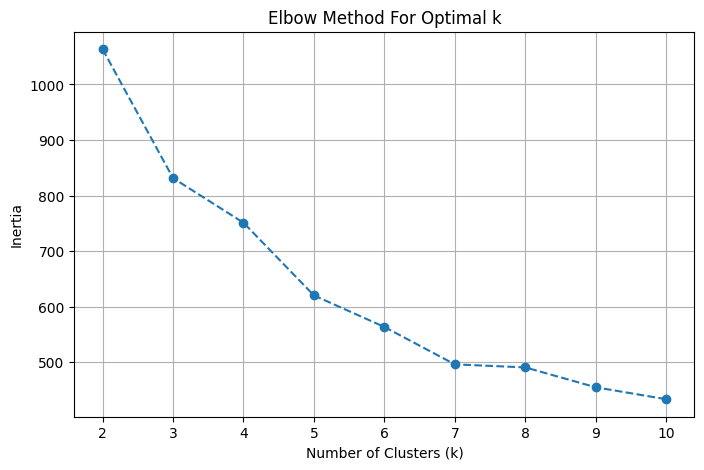

In [5]:
inertia_values = []
k_range = range(2, 11) # Tests k from 2 to 10

# Run the optimization loop
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    inertia_values.append(kmeans.inertia_)

# Chart the curve in an Elbow Method line plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [6]:
# Define baseline cluster count
best_k = 3

# Train K-Means model
kmeans_model = KMeans(n_clusters=best_k, random_state=42)
cluster_labels = kmeans_model.fit_predict(scaled_df)

# Add the cluster assignments back to our original dataset so we know who is who
df['KMeans_Cluster'] = cluster_labels

# Evaluate performance
sil_score = silhouette_score(scaled_df, cluster_labels)
print(f"K-Means Silhouette Score: {sil_score:.4f}")

K-Means Silhouette Score: 0.2856


In [7]:
# Build secondary comparative model using exact parameters required
dbscan_model = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan_model.fit_predict(scaled_df)

df['DBSCAN_Cluster'] = dbscan_labels
print("DBSCAN clustering complete.")

DBSCAN clustering complete.


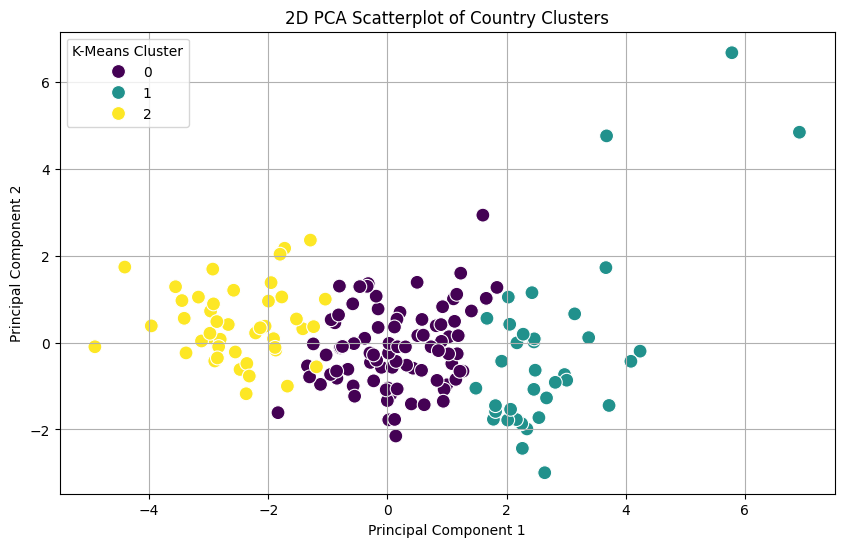

In [8]:
# Project high-dimensional records into 2D
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)

# Map to a DataFrame for plotting
pca_df = pd.DataFrame(data=pca_components, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = df['KMeans_Cluster']

# Map K-Means classifications to a color-coded scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', palette='viridis', data=pca_df, s=100)
plt.title('2D PCA Scatterplot of Country Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='K-Means Cluster')
plt.grid(True)
plt.show()

In [9]:

df.groupby('KMeans_Cluster').mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442,-0.069767
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111,-0.333333


personal opinion:I have seen that clusters overlap and we got negative silhoutee score I think we need to change eps value in dbscan or may be the data itself is not seperable

#final section(section 14) containing final observations from the clusters data

For Cluster 2, the data shows a clear high-mortality cluster. The average child mortality here is extremely high at about 95 deaths per 1000 births, and the people have the lowest life expectancy at around 59 years. Because of the low average income of $3539 and a very low GDP percapita income of 1766 dollars.this group clearly represents low-development areas. These nations are struggling the most with basic healthcare and economic stability.

On the complete opposite end, Cluster 1 represents the top-tier economic zones. These are wealthy, highly developed countries. This is evident from their massive average GDP per capita of $42,494 and high income levels. This wealth translates directly to better healthcare, as their child mortality drops all the way down to 5 and life expectancy jumps to over 80 years

Finally, Cluster 0 is the middle ground between the two extremes. They aren't nearly as wealthy as the top-tier zones, with a GDP per capita of only $6,461, but they are doing much better than the low-development areas. Life expectancy is pretty average at 72 years. Basically, these are developing nations that are making steady progress but still have a gap to close when compared to the top-tier countries.